In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [5]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/celeba-dataset
['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [9]:
import os
import shutil

source_folder = os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder = "celeba_small/faces"

# Create folder
os.makedirs(destination_folder, exist_ok=True)

# Take first 5000 images
images = sorted(os.listdir(source_folder))[:5000]

# Copy images
for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        os.path.join(destination_folder, img)
    )

print("Copied", len(os.listdir(destination_folder)), "images")

Copied 5000 images


In [10]:
print(os.listdir(os.path.join(path, "img_align_celeba")))

['img_align_celeba']


In [8]:
import os

print(os.listdir(path))
print(os.listdir(os.path.join(path, "img_align_celeba"))[:10])

['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']
['img_align_celeba']


In [11]:
#data preprocessing
IMAGE_SIZE=(64,64)
BATCH_SIZE=32


In [12]:
datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [13]:
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [14]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


In [15]:
images, _ = next(train_generator)

print(images.shape)

(32, 64, 64, 3)


In [17]:
# Encoder
input_img = Input(shape=(64,64,3))

x = Conv2D(32,(3,3),activation="relu",padding="same")(input_img)
x = MaxPooling2D((2,2),padding="same")(x)

x = Conv2D(64,(3,3),activation="relu",padding="same")(x)
encoded = MaxPooling2D((2,2),padding="same")(x)

# Decoder
x = Conv2D(64,(3,3),activation="relu",padding="same")(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation="relu",padding="same")(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3,(3,3),activation="sigmoid",padding="same")(x)

In [18]:
autoencoder = Model(input_img, decoded)

In [19]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [20]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 0.5286 - val_loss: 0.4955
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.4915 - val_loss: 0.4888
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.4882 - val_loss: 0.4868
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4865 - val_loss: 0.4865
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.4853 - val_loss: 0.4855
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.4843 - val_loss: 0.4847
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.4837 - val_loss: 0.4833
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.4833 - val_loss: 0.4829
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.4836 - val_loss: 0.4836
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.4824 - val_loss: 0.4840


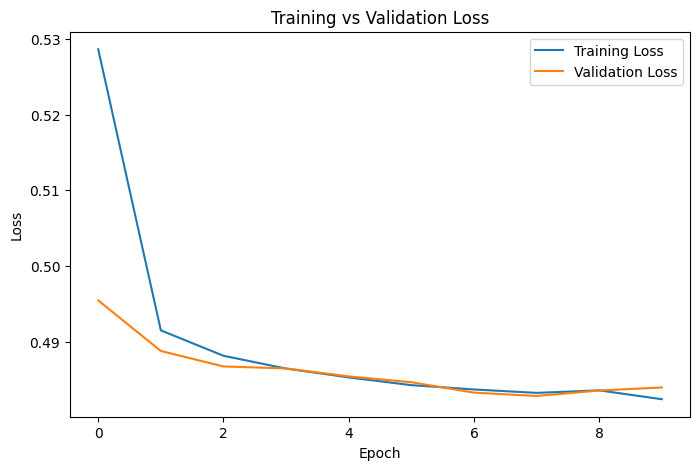

In [22]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [23]:
# Get one batch
test_images, _ = next(validation_generator)

# Predict
decoded_images = autoencoder.predict(test_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step


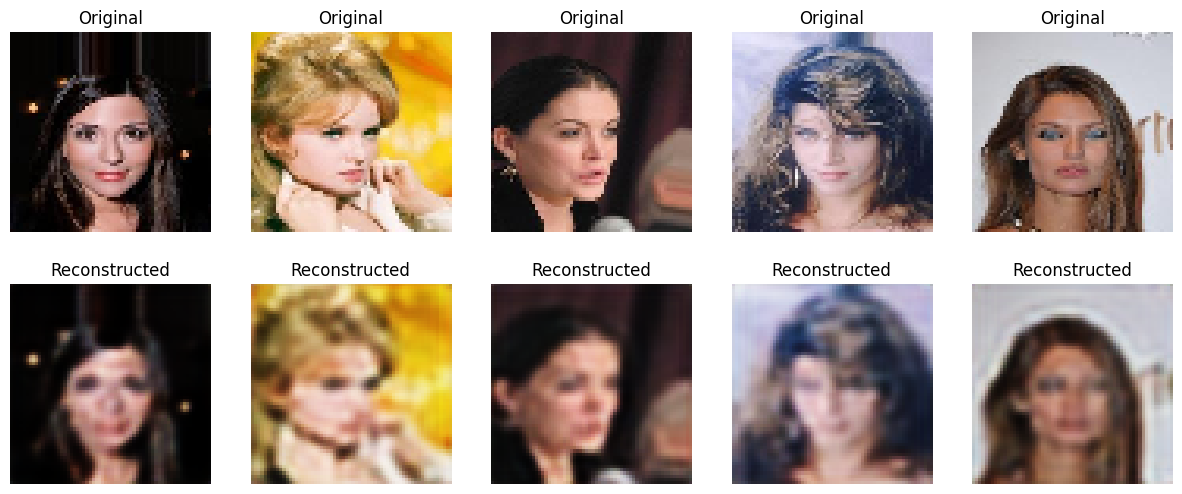

In [24]:
import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(15,6))

for i in range(n):

    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(test_images[i])
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, n, i+n+1)
    plt.imshow(decoded_images[i])
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

In [25]:
autoencoder.save("celeba_autoencoder.keras")

In [26]:
encoder = Model(input_img, encoded)
encoder.save("encoder.keras")

In [27]:
import numpy as np

mse = np.mean((test_images - decoded_images) ** 2)

print("Reconstruction MSE:", mse)

Reconstruction MSE: 0.005284952
